### Testing script of the CNN model
#### TODO:

+ Check how to improve the adaptive one so we can get similar scores
+ Make sure to save the other options still!!
+ Data Augmentation options!!

**At the end**
+ Make it all in a script to be run from command line
+ Add argument parsing for hyperparameters


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import sys
from pathlib import Path
sys.path.append(str(Path("..").resolve()))

# Local imports
from cnn import SimpleCNN, SimpleAdaptiveCNN
from data.load_cifar import CIFAR10
from train import train_model
from analysis.evaluation import evaluate_model

# Device selection (prep for potential GPU usage in e.g Colab)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Create datasets
train_dataset = CIFAR10(split="train")
test_dataset  = CIFAR10(split="test")

# Class names in CIFAR-10
class_names = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck" ]

# Create dataloaders
trainloader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

valloader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

# check the "batching"
images, labels = next(iter(trainloader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Image dtype:", images.dtype)
print("Label dtype:", labels.dtype)

Using device: cpu
Train samples: 50000
Test samples: 10000


/Users/reiterer/MachineLearningWS25/ML_TU_WS25/Exercise3/data/load_cifar.py:24: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  dict = pickle.load(fo, encoding="bytes")
/Users/reiterer/MachineLearningWS25/ML_TU_WS25/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Image batch shape: torch.Size([128, 3, 32, 32])
Label batch shape: torch.Size([128])
Image dtype: torch.float32
Label dtype: torch.int64


Training model: SimpleCNN
SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=2048, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)
Starting training...

Epoch 1/10


Training:   0%|          | 0/391 [00:00<?, ?it/s]/Users/reiterer/MachineLearningWS25/ML_TU_WS25/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Train Loss: 1.6869 | Train Acc: 0.3835
Train Time: 42.34s
Val   Loss: 1.3903 | Val   Acc: 0.4863
Val   Time: 13.28s

Epoch 2/10


Train Loss: 1.3239 | Train Acc: 0.5225
Train Time: 42.44s
Val   Loss: 1.1487 | Val   Acc: 0.5872
Val   Time: 13.81s

Epoch 3/10


Train Loss: 1.1533 | Train Acc: 0.5872
Train Time: 41.60s
Val   Loss: 1.0460 | Val   Acc: 0.6333
Val   Time: 13.83s

Epoch 4/10


...

Train Loss: 0.8796 | Train Acc: 0.6937
Train Time: 41.98s
Val   Loss: 0.8334 | Val   Acc: 0.7030
Val   Time: 13.61s

Epoch 7/10


Train Loss: 0.8165 | Train Acc: 0.7149
Train Time: 41.81s
Val   Loss: 0.8310 | Val   Acc: 0.7077
Val   Time: 13.48s

Epoch 8/10


Train Loss: 0.7721 | Train Acc: 0.7303
Train Time: 42.20s
Val   Loss: 0.7822 | Val   Acc: 0.7251
Val   Time: 14.13s

Epoch 9/10


Train Loss: 0.7178 | Train Acc: 0.7487
Train Time: 42.19s
Val   Loss: 0.7627 | Val   Acc: 0.7341
Val   Time: 13.92s

Epoch 10/10


Train Loss: 0.6850 | Train Acc: 0.7593
Train Time: 41.98s
Val   Loss: 0.7492 | Val   Acc: 0.7400
Val   Time: 13.70s

Total Training Time  : 418.46s
Total Validation Time: 137.38s


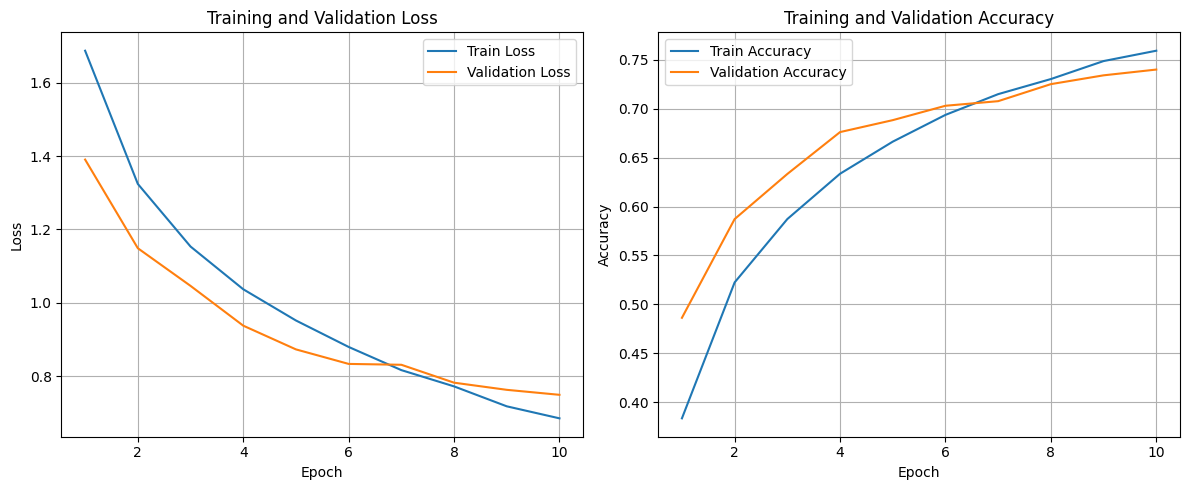

Training completed.
Saved trained model to: cnn_trained_models/simplecnn_cifar10_v1.pth
Evaluating trained model on validation set...
Final validation accuracy: 0.7400

Model Evaluation
----------------
Overall accuracy: 0.7400

Per-class accuracy:
  airplane: 0.818
automobile: 0.907
      bird: 0.602
       cat: 0.571
      deer: 0.686
       dog: 0.652
      frog: 0.793
     horse: 0.791
      ship: 0.813
     truck: 0.767

Classification report:
              precision    recall  f1-score   support

    airplane      0.731     0.818     0.772      1000
  automobile      0.787     0.907     0.843      1000
        bird      0.667     0.602     0.633      1000
         cat      0.566     0.571     0.568      1000
        deer      0.715     0.686     0.700      1000
         dog      0.631     0.652     0.641      1000
        frog      0.798     0.793     0.795      1000
       horse      0.787     0.791     0.789      1000
        ship      0.865     0.813     0.838      1000
      

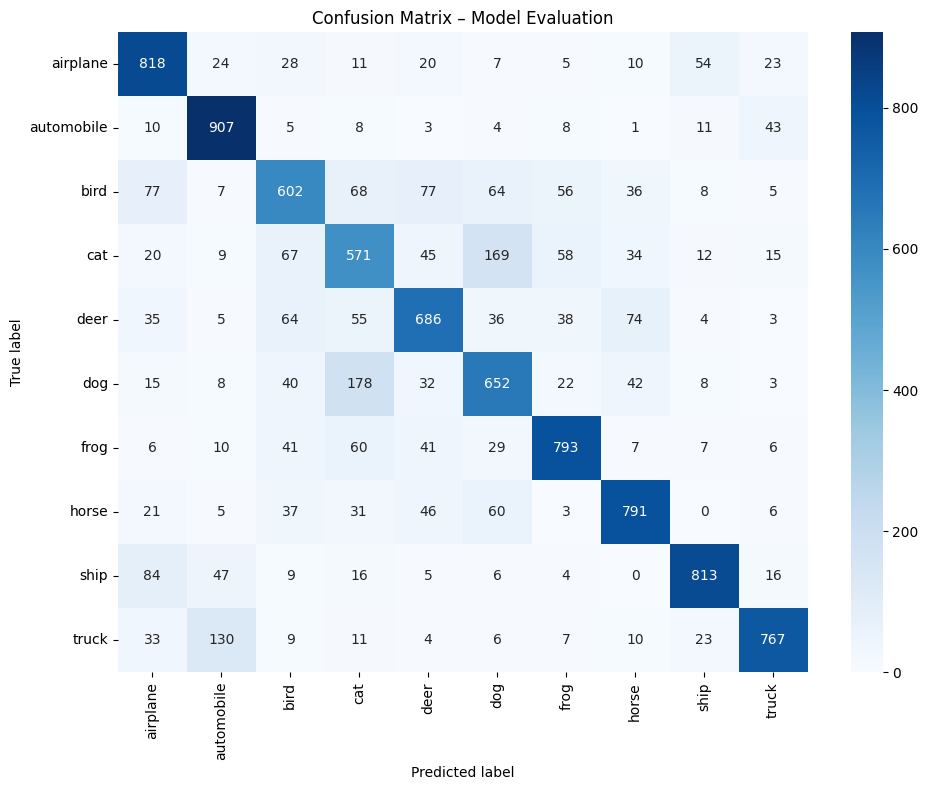

Training model: SimpleAdaptiveCNN
SimpleAdaptiveCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (gap): AdaptiveAvgPool2d(output_size=(1, 1))
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)
Starting training...

Epoch 1/10


Training:   0%|          | 0/391 [00:00<?, ?it/s]/Users/reiterer/MachineLearningWS25/ML_TU_WS25/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Train Loss: 1.9065 | Train Acc: 0.2717
Train Time: 41.26s
Val   Loss: 1.6798 | Val   Acc: 0.3795
Val   Time: 13.51s

Epoch 2/10


Train Loss: 1.6156 | Train Acc: 0.3924
Train Time: 41.82s
Val   Loss: 1.5738 | Val   Acc: 0.4050
Val   Time: 14.42s

Epoch 3/10


Train Loss: 1.4875 | Train Acc: 0.4489
Train Time: 41.50s
Val   Loss: 1.3757 | Val   Acc: 0.4900
Val   Time: 13.65s

Epoch 4/10


...

Train Loss: 1.2533 | Train Acc: 0.5459
Train Time: 41.52s
Val   Loss: 1.1889 | Val   Acc: 0.5715
Val   Time: 13.71s

Epoch 7/10


Train Loss: 1.1994 | Train Acc: 0.5648
Train Time: 41.97s
Val   Loss: 1.1173 | Val   Acc: 0.5977
Val   Time: 13.49s

Epoch 8/10


Train Loss: 1.1514 | Train Acc: 0.5824
Train Time: 41.14s
Val   Loss: 1.0925 | Val   Acc: 0.6046
Val   Time: 13.74s

Epoch 9/10


Train Loss: 1.1131 | Train Acc: 0.5984
Train Time: 41.29s
Val   Loss: 1.0479 | Val   Acc: 0.6223
Val   Time: 13.48s

Epoch 10/10


Train Loss: 1.0677 | Train Acc: 0.6171
Train Time: 45.25s
Val   Loss: 1.0596 | Val   Acc: 0.6129
Val   Time: 14.00s

Total Training Time  : 418.10s
Total Validation Time: 137.96s


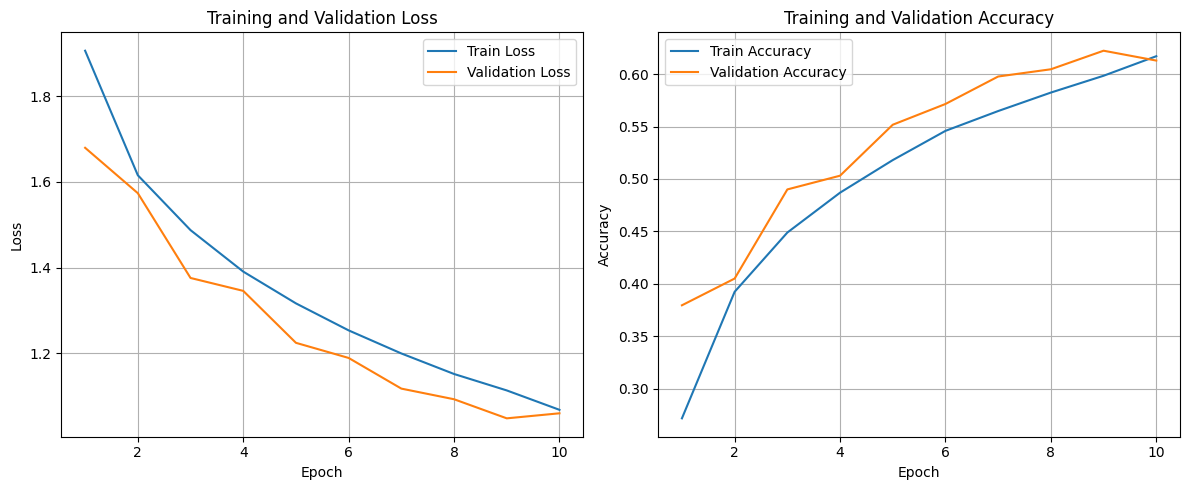

Training completed.
Saved trained model to: cnn_trained_models/simpleadaptivecnn_cifar10_v1.pth
Evaluating trained model on validation set...
Final validation accuracy: 0.6129

Model Evaluation
----------------
Overall accuracy: 0.6129

Per-class accuracy:
  airplane: 0.729
automobile: 0.888
      bird: 0.579
       cat: 0.182
      deer: 0.325
       dog: 0.719
      frog: 0.619
     horse: 0.740
      ship: 0.675
     truck: 0.673

Classification report:
              precision    recall  f1-score   support

    airplane      0.660     0.729     0.693      1000
  automobile      0.684     0.888     0.773      1000
        bird      0.456     0.579     0.510      1000
         cat      0.415     0.182     0.253      1000
        deer      0.673     0.325     0.438      1000
         dog      0.409     0.719     0.521      1000
        frog      0.762     0.619     0.683      1000
       horse      0.628     0.740     0.680      1000
        ship      0.870     0.675     0.760      100

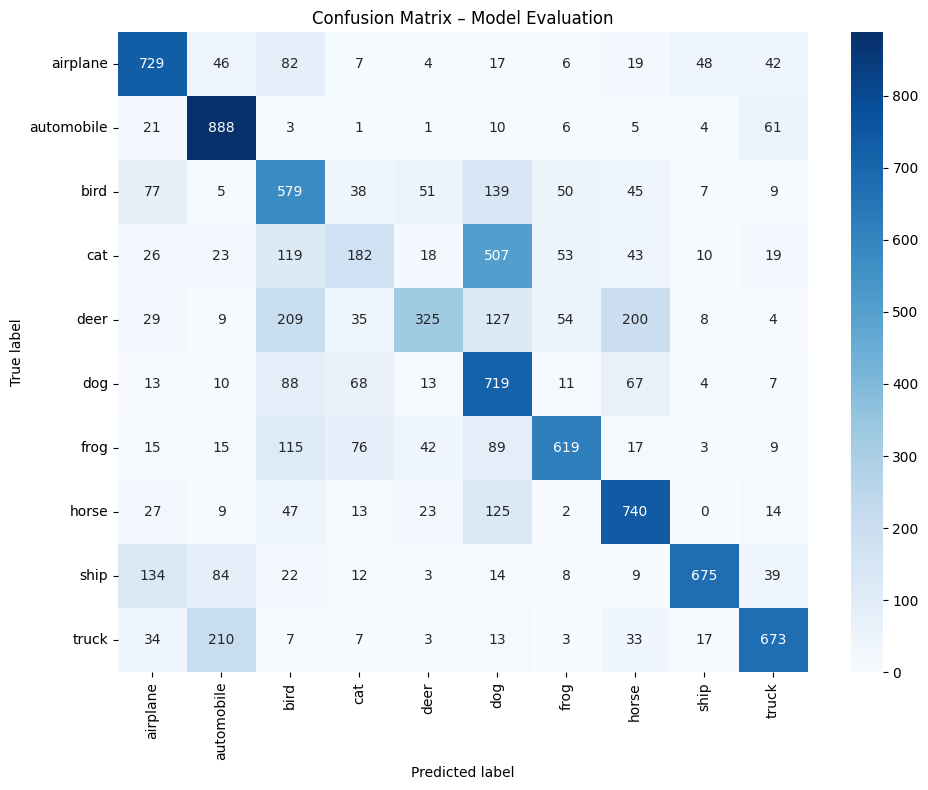

In [2]:
in_channels = 3
num_classes = 10
input_size = 32
base_channels = 32
channel_multiplier = 2

model_selection = {"SimpleCNN": SimpleCNN(
                                in_channels=in_channels,
                                num_classes=num_classes,
                                input_size=input_size,
                                base_channels=base_channels,
                                channel_multiplier=channel_multiplier), 
                    "SimpleAdaptiveCNN": SimpleAdaptiveCNN(
                                in_channels=in_channels,
                                num_classes=num_classes,
                                base_channels=base_channels,
                                channel_multiplier=channel_multiplier)
                                }

for model_name, model in model_selection.items():
    print(f"Training model: {model_name}")
    # Set the model to the device (GPU/CPU)
    model = model.to(device)
    print(model)

    # Prepare Loss function and optimizer
    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=1e-3
    )

    print("Starting training...")
    # Train the model
    trained_model = train_model(
        model=model,
        trainloader=trainloader,
        valloader=valloader,
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        epochs=10
        )
    print("Training completed.")    

    # Save the trained model and check for exisiting files/dirs 
    Path("cnn_trained_models").mkdir(exist_ok=True)
    file_name = f"cnn_trained_models/{model_name.lower()}_cifar10.pth"
    
    # Check if file exists and append version number
    base_path = Path(file_name)
    if base_path.exists():
        version = 1
        while (base_path.parent / f"{base_path.stem}_v{version}{base_path.suffix}").exists():
            version += 1
        file_name = str(base_path.parent / f"{base_path.stem}_v{version}{base_path.suffix}")

    torch.save(trained_model.state_dict(), file_name)
    print("Saved trained model to:", file_name)
    
    print("Evaluating trained model on validation set...")
    trained_model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in valloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = trained_model(images)
            _, preds = outputs.max(1)

            correct += preds.eq(labels).sum().item()
            total += labels.size(0)

    print(f"Final validation accuracy: {correct / total:.4f}")

    evaluate_model(trained_model, valloader, device=device, class_names=class_names)

    del trained_model

In [ ]:
trained_model = train_model(
    model=model,
    trainloader=trainloader,
    valloader=valloader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    epochs=10
)


Epoch 1/10


Training:   0%|          | 0/391 [00:00<?, ?it/s]/Users/reiterer/Library/CloudStorage/OneDrive-Persönlich/TU Wien/MSc Data Science/WS25/MachineLearning/Exercise3/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
Training: 100%|██████████| 391/391 [00:33<00:00, 12.43it/s]

In [ ]:
# save the trained model
file_name = "cnn_trained_models/simple_cnn_cifar10_v2.pth"
torch.save(trained_model.state_dict(), file_name)
#del trained_model

In [8]:
# load the saved model with the same parameters initially set
trained_model = SimpleCNN(in_channels=3, num_classes=10, input_size=32, base_channels=32, channel_multiplier=2)
trained_model.load_state_dict(torch.load(file_name))

<All keys matched successfully>

In [9]:
trained_model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in valloader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = trained_model(images)
        _, preds = outputs.max(1)

        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

print(f"Final validation accuracy: {correct / total:.4f}")


Final validation accuracy: 0.7299


In [10]:
from analysis.evaluation import evaluate_model

/Users/reiterer/Library/CloudStorage/OneDrive-Persönlich/TU Wien/MSc Data Science/WS25/MachineLearning/Exercise3/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)



Model Evaluation
----------------
Overall accuracy: 0.7299

Per-class accuracy:
  airplane: 0.861
automobile: 0.890
      bird: 0.627
       cat: 0.534
      deer: 0.649
       dog: 0.521
      frog: 0.822
     horse: 0.799
      ship: 0.852
     truck: 0.744

Classification report:
              precision    recall  f1-score   support

    airplane      0.643     0.861     0.736      1000
  automobile      0.807     0.890     0.846      1000
        bird      0.637     0.627     0.632      1000
         cat      0.554     0.534     0.544      1000
        deer      0.720     0.649     0.682      1000
         dog      0.719     0.521     0.604      1000
        frog      0.800     0.822     0.811      1000
       horse      0.757     0.799     0.778      1000
        ship      0.824     0.852     0.838      1000
       truck      0.859     0.744     0.797      1000

    accuracy                          0.730     10000
   macro avg      0.732     0.730     0.727     10000
weighted av

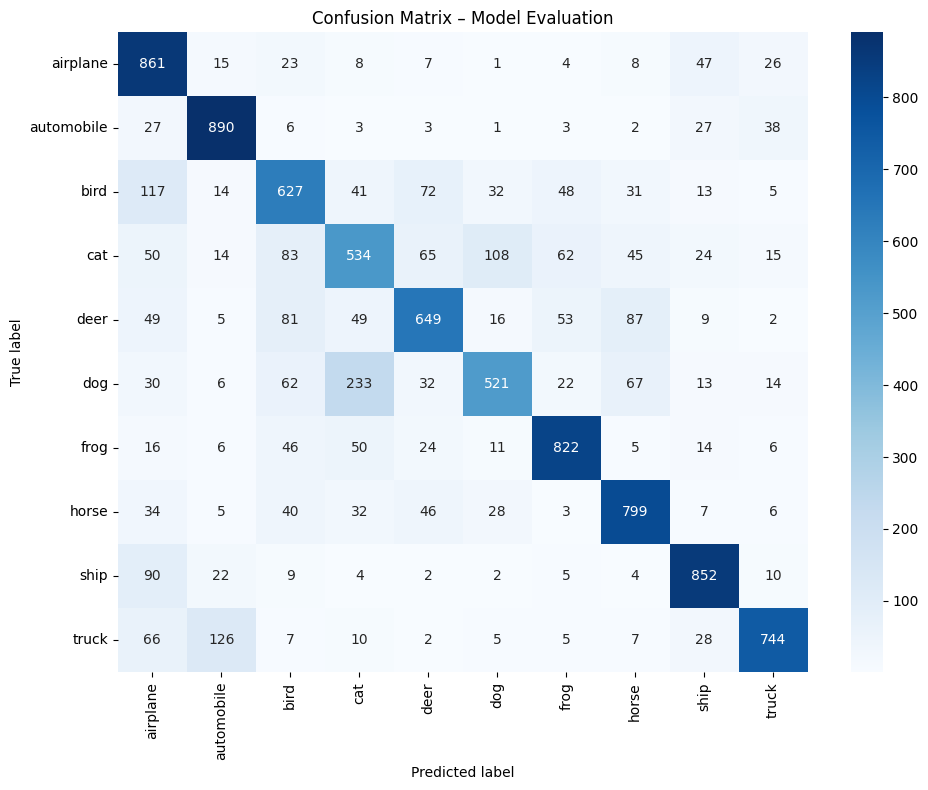

{'overall_accuracy': 0.7299000024795532,
 'per_class_accuracy': array([0.861, 0.89 , 0.627, 0.534, 0.649, 0.521, 0.822, 0.799, 0.852,
        0.744]),
 'confusion_matrix': array([[861,  15,  23,   8,   7,   1,   4,   8,  47,  26],
        [ 27, 890,   6,   3,   3,   1,   3,   2,  27,  38],
        [117,  14, 627,  41,  72,  32,  48,  31,  13,   5],
        [ 50,  14,  83, 534,  65, 108,  62,  45,  24,  15],
        [ 49,   5,  81,  49, 649,  16,  53,  87,   9,   2],
        [ 30,   6,  62, 233,  32, 521,  22,  67,  13,  14],
        [ 16,   6,  46,  50,  24,  11, 822,   5,  14,   6],
        [ 34,   5,  40,  32,  46,  28,   3, 799,   7,   6],
        [ 90,  22,   9,   4,   2,   2,   5,   4, 852,  10],
        [ 66, 126,   7,  10,   2,   5,   5,   7,  28, 744]]),
 'predictions': tensor([3, 8, 8,  ..., 5, 4, 7]),
 'labels': tensor([3, 8, 8,  ..., 5, 1, 7])}

In [11]:
class_names = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck" ]
evaluate_model(trained_model, valloader, device="cpu", class_names=class_names)

In [21]:
# target output size of 5x7
m = nn.AdaptiveAvgPool2d((5, 7))
input = torch.randn(1, 64, 8, 9)
output = m(input)
print(output.shape)

# target output size of 7x7 (square)
m = nn.AdaptiveAvgPool2d(7)
input = torch.randn(1, 64, 10, 9)
output = m(input)
print(output.shape)

# target output size of 10x7
m = nn.AdaptiveAvgPool2d((None, 7))
input = torch.randn(1, 64, 10, 9)
output = m(input)
print(output.shape)

# target output size of 15x15
m = nn.AdaptiveAvgPool2d((15, 15))
input = torch.randn(1, 64, 10, 9)
output = m(input)
print(output.shape)

# target output size of the same size
m = nn.AdaptiveAvgPool2d((2,2))
input = torch.randn(1, 6, 2, 2)
output = m(input)
print(output.shape)


torch.Size([1, 64, 5, 7])
torch.Size([1, 64, 7, 7])
torch.Size([1, 64, 10, 7])
torch.Size([1, 64, 15, 15])
torch.Size([1, 6, 2, 2])


In [23]:
input , output

(tensor([[[[-0.9263, -0.5816],
           [-1.1925, -0.3591]],
 
          [[ 0.8660, -0.3756],
           [-2.2855,  1.0001]],
 
          [[-1.5795, -0.2661],
           [-0.6010, -1.2038]],
 
          [[ 1.5281,  1.4366],
           [ 1.2875, -1.0313]],
 
          [[-1.2212, -0.4418],
           [-0.2393,  0.5293]],
 
          [[ 0.0678, -0.5407],
           [ 1.0346,  0.4056]]]]),
 tensor([[[[-0.9263, -0.5816],
           [-1.1925, -0.3591]],
 
          [[ 0.8660, -0.3756],
           [-2.2855,  1.0001]],
 
          [[-1.5795, -0.2661],
           [-0.6010, -1.2038]],
 
          [[ 1.5281,  1.4366],
           [ 1.2875, -1.0313]],
 
          [[-1.2212, -0.4418],
           [-0.2393,  0.5293]],
 
          [[ 0.0678, -0.5407],
           [ 1.0346,  0.4056]]]]))